Desenvolvimento de IA para Análise Preditiva [T3] - M1S13 - Projeto Final Módulo 1 - 06/10/2026

Aluna: Isabela Gomes da Costa

DESAFIO:

Atuar como Cientista de Dados para estruturar um Pipeline Preditivo completo aplicado à Indústria 4.0.

O Problema: Um parque fabril monitorado por sensores necessita prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção. A variável alvo do projeto é binária: Falha = 1 (quando há uma avaria detectada) e Falha = 0 (funcionamento normal).

Link da Base de Dados (.csv): https://drive.google.com/drive/folders/1_QcYvhSoJO6SxOJz8Om6gaVuWyPZKdMs?usp=sharing

Além da base de dados, o engenheiro responsável disponibilizou alguns detalhes importantes que você precisa levar em consideração: anotações do Departamento de Engenharia.


0 - Ambiente e importações

In [4]:
# Instalando SMOTE
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Importação de Bibliotecas de terceiros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from imblearn.over_sampling import SMOTE

pd.set_option("display.width", 120)
sns.set_style("whitegrid")

print("Ambiente pronto!")

Ambiente pronto!


Fase 1: Análise Exploratória (EDA)

In [6]:
# Carregando o dataset
url_dados = (
    "https://drive.google.com/uc?export=download"
    "&id=1er0sPjY51RymKrRkzZkjFOVwJ8PEZoAZ"
)

df = pd.read_csv(url_dados)

display(df.head())
print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas")

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


Dimensões: 10000 linhas e 14 colunas


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

Verificando os tipos dos dados, temos que todas as colunas estão de acordo com o que é especificado no documento "Anotações do Departamento de Engenharia". Além disso, podemos verificar que há 500 valores nulos nas colunas temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm.

In [8]:
display(df.describe())

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Analisando os valores estatísticos (percepções iniciais), temos:

temperatura_ar_k e temperatura_processo_k: variáveis com comportamento similar, além de possírem a mesma escala, variação pequena entre os valores máximos e mínimos, além de desvios padrão baixos. 

velocidade_rotacao_rpm: nessa coluna algo me chamou bastante atenção, seu desvio padrão, e olhando a distribuição dos quartis, já tenho um indicativo de um possível outlier, pois, até 75% dos dados, os valores aumentam de uma maneira quase constante, mas no último quartil, há um grande salto no valor, este que difere muito da média.

torque_nm e desgaste_ferramenta_min: aqui tem-se um comportamento similar ao anterior, valores máximos longe das médias, desvios padrão relativamente altos.

dados de falha: estes valores são binárias, codificadas como 0 e 1, então a interpretação estatística pelo describe não é muito informativa, visualizarei eles melhor através dos gráficos a seguir. No entanto, vale pontuar que as variáveis possuem médias bem baixas, e apenas o valor máximo preechido pelo valor 1, ou seja, vemos que a maior parte das linhas são referentes a equipamentos sem falha, ou seja, isso já implica um desbalanceamento na base de dados que deverá ser tratado posteriormente.


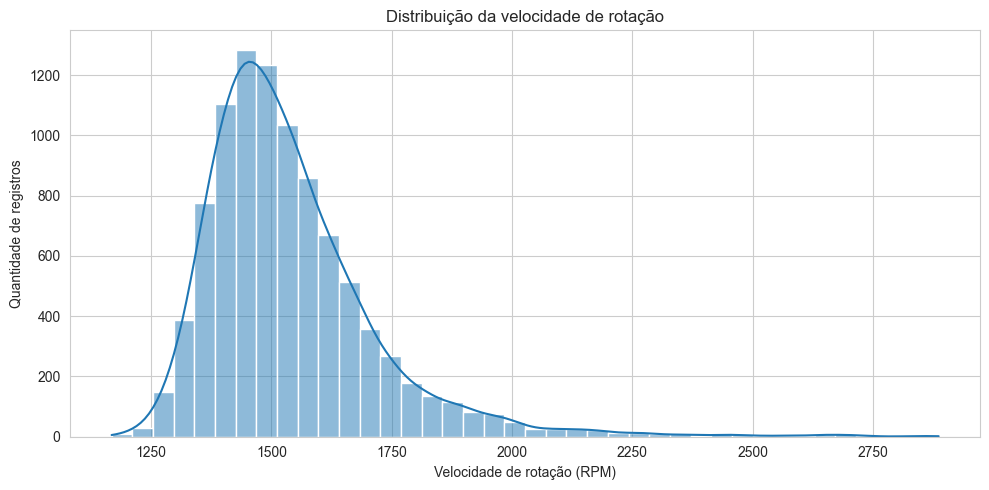

In [9]:
# Gráficos iniciais

# Gráfico de histograma para confirmar se minha percepção sobre a velocidade de rotação está correta

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="velocidade_rotacao_rpm",
    bins=40,
    kde=True
)

plt.title("Distribuição da velocidade de rotação")
plt.xlabel("Velocidade de rotação (RPM)")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O gráfico confirma a distribuição assimétrica que percebi anteriormente, onde a maior concentração está aproximadamente entre 1.400 e 1.600 RPM (cauda alongada à direita), com poucas observações chegando perto de 2.900 RPM.

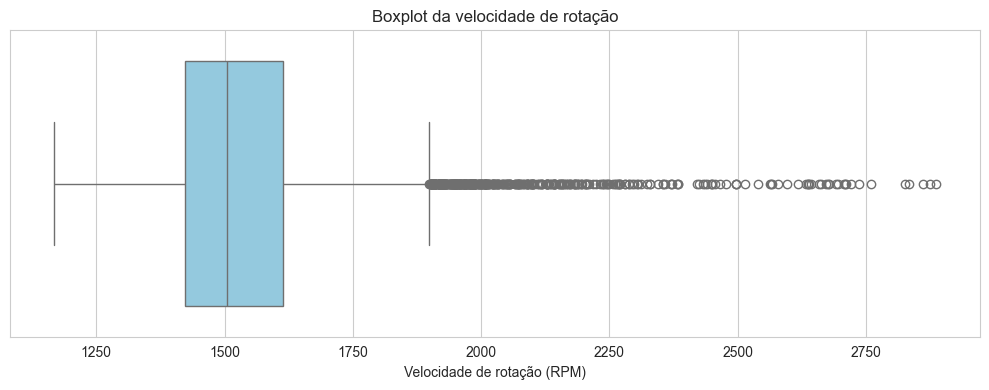

In [10]:
# Gráfico de boxplot para verificar a presença de outliers na variável velocidade de rotação

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="velocidade_rotacao_rpm",
    color="skyblue"
)

plt.title("Boxplot da velocidade de rotação")
plt.xlabel("Velocidade de rotação (RPM)")
plt.tight_layout()
plt.show()

O boxplox demonstra mais claramente os valores extremos acima de 1.898 RPM, reforçando a assimetria à direita observada no histograma. Como, mesmo sendo outliers, são diversos valores, isso corrobora para a interpretação de que são inerentes aos processos dos equipamentos, e não dados errôneos, ou, se fossem poucos registros nessa situação, algo pontual, então eles  serão mantidos por enquanto.

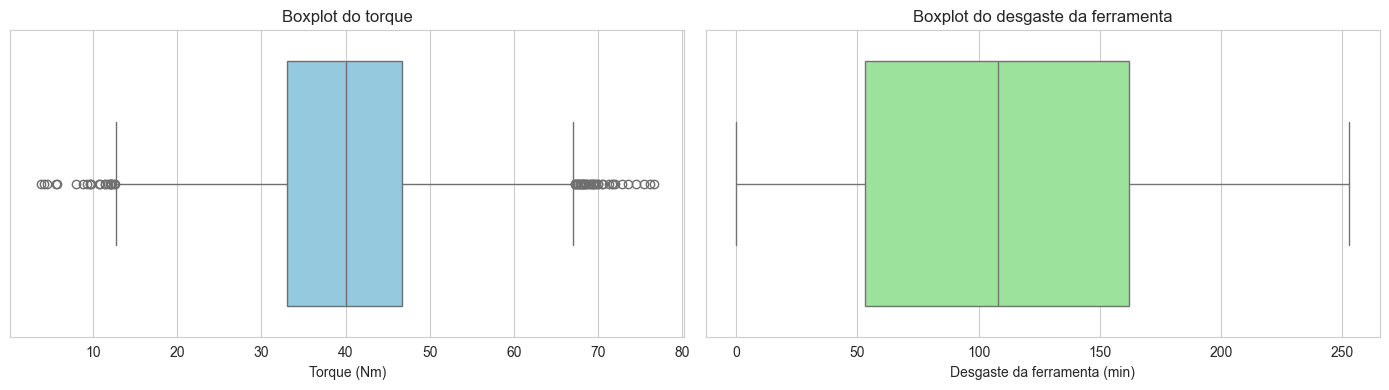

In [11]:
# Gráfico de boxplot para verificar a presença de outliers nas variáveis torque e desgaste de ferramenta

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=df,
    x="torque_nm",
    color="skyblue",
    ax=axes[0]
)
axes[0].set_title("Boxplot do torque")
axes[0].set_xlabel("Torque (Nm)")

sns.boxplot(
    data=df,
    x="desgaste_ferramenta_min",
    color="lightgreen",
    ax=axes[1]
)
axes[1].set_title("Boxplot do desgaste da ferramenta")
axes[1].set_xlabel("Desgaste da ferramenta (min)")

plt.tight_layout()
plt.show()

Anteriormente identifiquei estes dados como similares, mas olhando melhor através do boxplot de cada um, vemos que o comportamento não é parecido. O torque apresenta valores extremos tanto abaixo quanto acima da faixa delimitada do boxplot. Já o desgaste da ferramenta, não apresenta outliers por esse método. Isso mostra que máximos distantes da média não são suficientes para determinar um outlier.



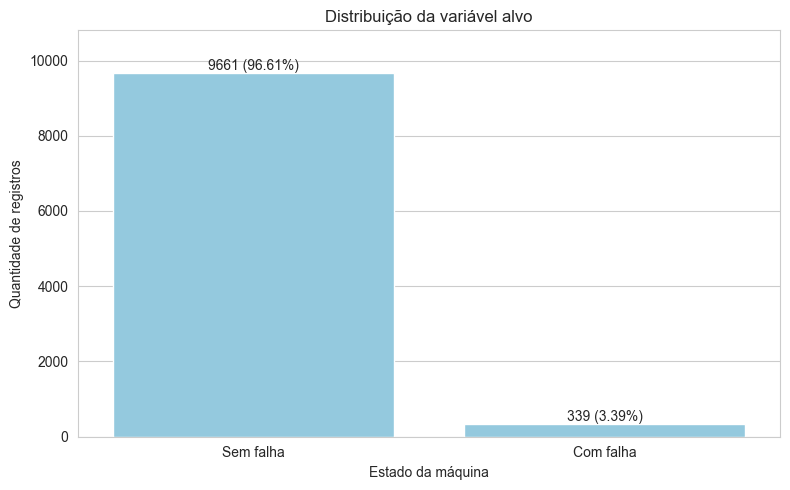

In [12]:
# Gráfico de distribuição da variável falha_maquina

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="falha_maquina",
    order=[0, 1],
    color="skyblue"
)

for barra in ax.patches:
    quantidade = int(barra.get_height())
    percentual = quantidade / len(df) * 100

    ax.annotate(
        f"{quantidade} ({percentual:.2f}%)",
        (barra.get_x() + barra.get_width() / 2, quantidade),
        ha="center",
        va="bottom"
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Sem falha", "Com falha"])
ax.set_ylim(0, len(df) * 1.08)

plt.title("Distribuição da variável alvo")
plt.xlabel("Estado da máquina")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O gráfico já informa de maneira explícita, 96,61% das medições não apresentam falha.

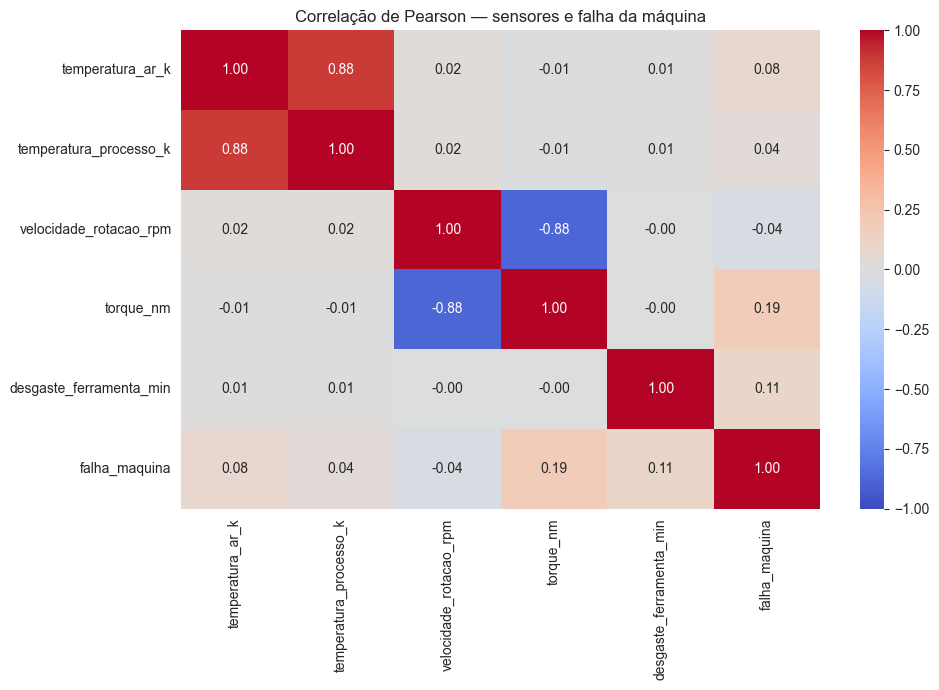

In [13]:
# Gráfico de correlação

colunas_correlacao = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "falha_maquina"
]

correlacao = df[colunas_correlacao].corr(method="pearson")

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlação de Pearson — sensores e falha da máquina")
plt.tight_layout()
plt.show()

Aqui a uma confirmação de algo que comentei inicialmente, as variáveis de temperatura possuem forte correlação positiva. Além disso, vale citar, que torque e velocidade apresentam forte correlação negativa. Essas associações não comprovam proporcionalidade ou causalidade.

Em relação à falha da máquina, variável alvo, torque (0,19) e desgaste da ferramenta (0,11) apresentam as maiores correlações positivas, embora sejam bem baixas. Porém, não descarto sua utilidade na modelagem, pois as falhas podem depender de relações não lineares.

Concluindo a primeira etapa do projeto, já há alguns direcionais para as próximas etapas. Terei que tratar/verificar os dados nulos, verificar a existência de dados duplicados, investigar as variáveis com valores extremos vistas nos boxplots, além de considerar o desbalanceamento do target no treino.